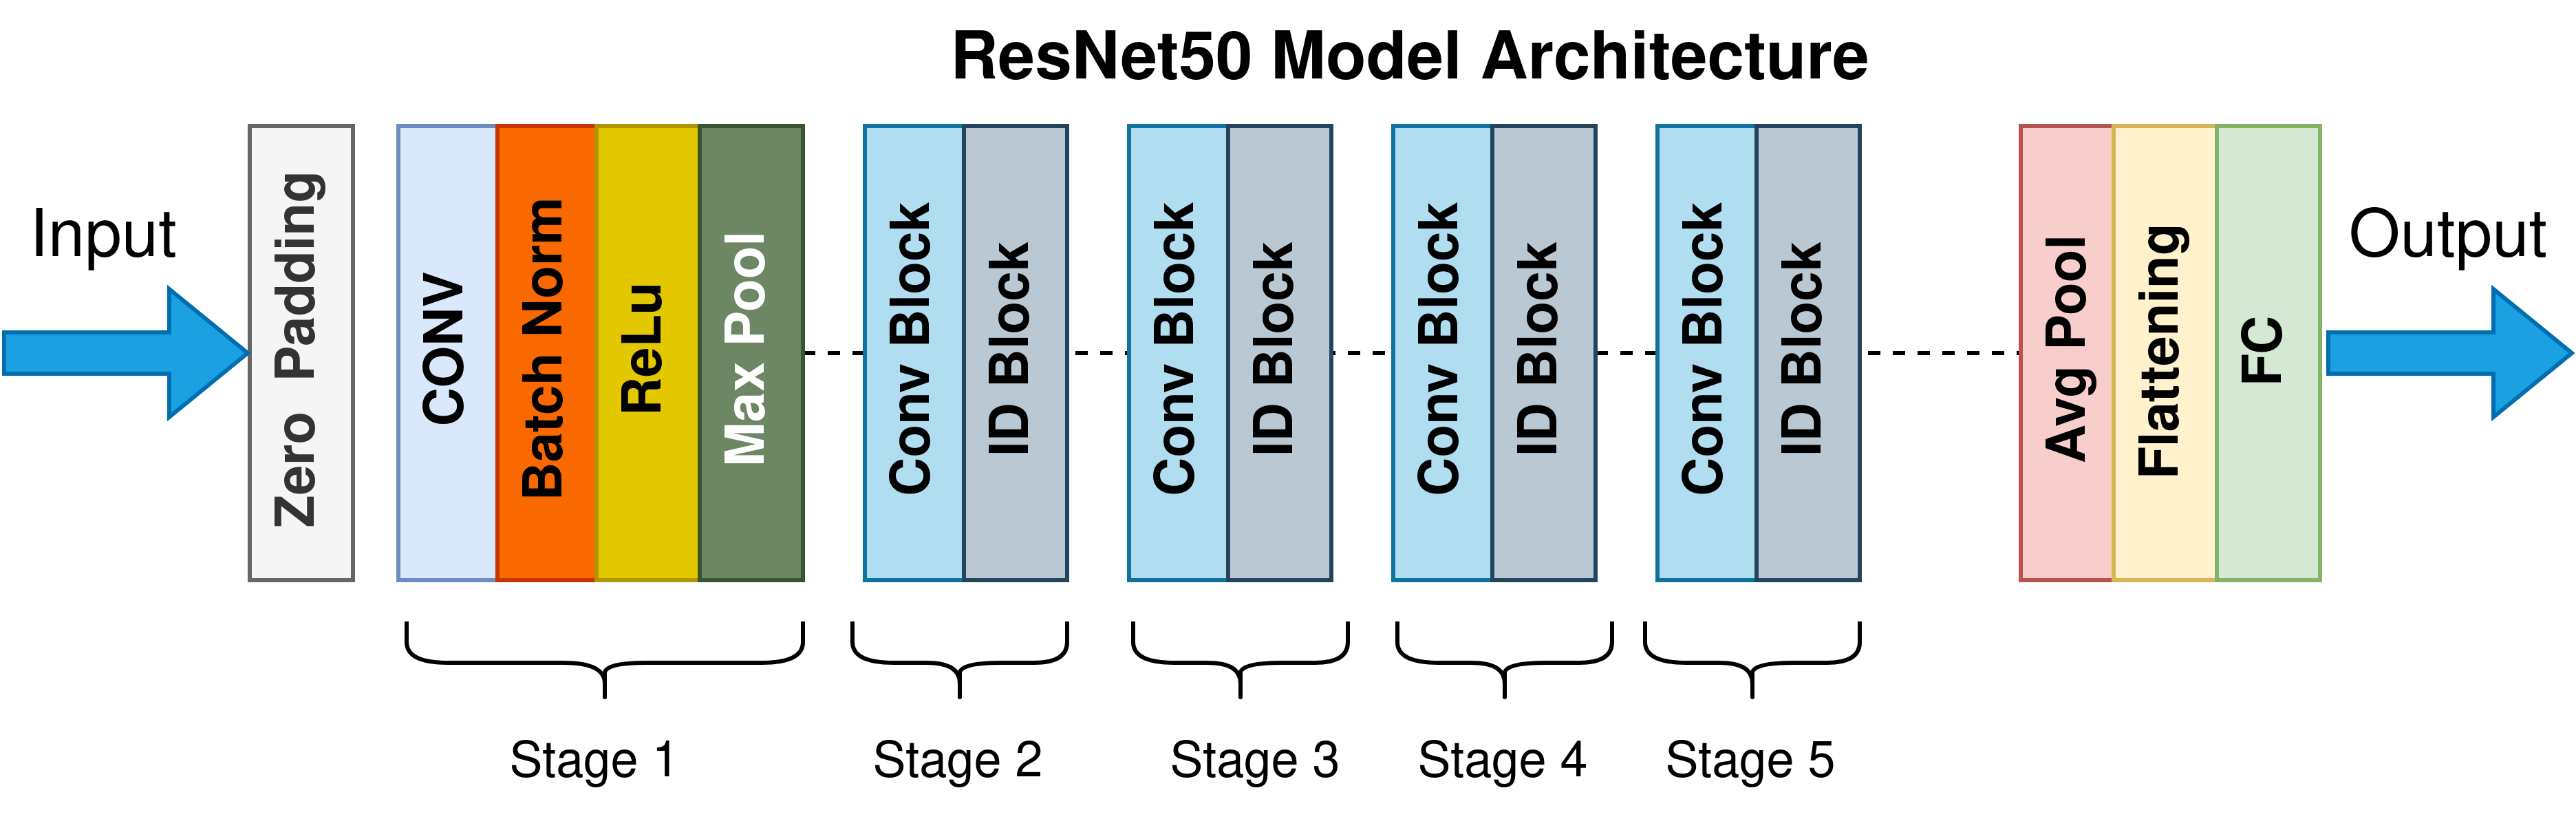

https://github.com/keras-team/keras/blob/v3.3.3/keras/src/applications/resnet.py#L48

In [1]:
import os
import shutil
import itertools
from glob import glob
from pathlib import Path
import json
import platform

In [2]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
)

import keras
import tensorflow as tf
from keras.models import Model
from keras.callbacks import EarlyStopping
from keras.utils import image_dataset_from_directory, get_file
from keras.applications.resnet50 import preprocess_input

import kagglehub

In [3]:
SEED = 42
keras.utils.set_random_seed(SEED)
TRAIN_FRACTION = 0.70
VALIDATION_FRACTION = 0.15
TEST_FRACTION = 0.15
DATASET_ID = "andrewmvd/lung-and-colon-cancer-histopathological-images"

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

TensorFlow: 2.20.0
Keras: 3.13.2


In [4]:
OUTPUT_DIR = Path("/content/exp-2-outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [5]:
assert TRAIN_FRACTION + VALIDATION_FRACTION + TEST_FRACTION == 1.0
print({
    "python": platform.python_version(),
    "pandas": pd.__version__,
    "scikit_learn": sklearn.__version__,
})

{'python': '3.12.13', 'pandas': '2.2.2', 'scikit_learn': '1.6.1'}


In [6]:
dataset_root = Path(kagglehub.dataset_download(DATASET_ID))

Using Colab cache for faster access to the 'lung-and-colon-cancer-histopathological-images' dataset.


In [7]:
colon_directories = list(dataset_root.rglob("colon_image_sets"))

if len(colon_directories) != 1:
    raise RuntimeError(
        f"Expected exactly one colon_image_sets directory, found {colon_directories}"
    )

colon_root = colon_directories[0]
print("Dataset root:", dataset_root)
print("Colon root:", colon_root)

Dataset root: /kaggle/input/lung-and-colon-cancer-histopathological-images
Colon root: /kaggle/input/lung-and-colon-cancer-histopathological-images/lung_colon_image_set/colon_image_sets


## 3. Build the binary index

The positive class is adenocarcinoma (`1`); benign tissue is class `0`. Stable relative paths make the manifest portable across Colab runtimes.

In [8]:
CLASS_MAPPING = {
    "colon_n": {"label": 0, "class_name": "benign"},
    "colon_aca": {"label": 1, "class_name": "adenocarcinoma"},
}
SUPPORTED_SUFFIXES = {".jpg", ".jpeg", ".png"}
records = []

for folder_name, class_info in CLASS_MAPPING.items():
    class_directory = colon_root / folder_name
    if not class_directory.is_dir():
        raise FileNotFoundError(f"Missing expected class directory: {class_directory}")

    image_paths = sorted(
        path for path in class_directory.iterdir()
        if path.is_file() and path.suffix.lower() in SUPPORTED_SUFFIXES
    )
    for image_path in image_paths:
        records.append({
            "relative_path": image_path.relative_to(colon_root).as_posix(),
            "filepath": str(image_path),
            "label": class_info["label"],
            "class_name": class_info["class_name"],
        })

image_index = pd.DataFrame.from_records(records).sort_values(
    ["label", "relative_path"]
).reset_index(drop=True)

expected_counts = {"benign": 5000, "adenocarcinoma": 5000}
actual_counts = image_index["class_name"].value_counts().to_dict()
assert actual_counts == expected_counts, (actual_counts, expected_counts)
assert len(image_index) == 10_000
assert image_index["relative_path"].is_unique
display(image_index.head())
display(image_index["class_name"].value_counts().sort_index())


,relative_path,filepath,label,class_name
0,colon_n/colonn1.jpeg,/kaggle/input/lung-and-colon-cancer-histopatho...,0,benign
1,colon_n/colonn10.jpeg,/kaggle/input/lung-and-colon-cancer-histopatho...,0,benign
2,colon_n/colonn100.jpeg,/kaggle/input/lung-and-colon-cancer-histopatho...,0,benign
3,colon_n/colonn1000.jpeg,/kaggle/input/lung-and-colon-cancer-histopatho...,0,benign
4,colon_n/colonn1001.jpeg,/kaggle/input/lung-and-colon-cancer-histopatho...,0,benign


,count
class_name,
adenocarcinoma,5000
benign,5000


## 4. Create train, validation, and test partitions

The test partition is isolated before model training. Validation is used for early stopping and model selection; test is evaluated only after the complete training procedure is fixed.


In [9]:
from sklearn.model_selection import train_test_split

train_df, temporary_df = train_test_split(
    image_index,
    test_size=VALIDATION_FRACTION + TEST_FRACTION,
    stratify=image_index["label"],
    random_state=SEED,
)

relative_test_fraction = TEST_FRACTION / (VALIDATION_FRACTION + TEST_FRACTION)
validation_df, test_df = train_test_split(
    temporary_df,
    test_size=relative_test_fraction,
    stratify=temporary_df["label"],
    random_state=SEED,
)

partitions = {
    "train": train_df.reset_index(drop=True),
    "validation": validation_df.reset_index(drop=True),
    "test": test_df.reset_index(drop=True),
}

for split_name, frame in partitions.items():
    print(f"{split_name}: {len(frame):,}")
    print(frame["class_name"].value_counts().sort_index().to_dict())


train: 7,000
{'adenocarcinoma': 3500, 'benign': 3500}
validation: 1,500
{'adenocarcinoma': 750, 'benign': 750}
test: 1,500
{'adenocarcinoma': 750, 'benign': 750}


## 5. Validate split integrity

These assertions prevent accidental overlap, missing images, duplicated assignments, and class imbalance.


In [10]:
expected_sizes = {"train": 7000, "validation": 1500, "test": 1500}
expected_per_class = {
    "train": {"adenocarcinoma": 3500, "benign": 3500},
    "validation": {"adenocarcinoma": 750, "benign": 750},
    "test": {"adenocarcinoma": 750, "benign": 750},
}

split_paths = {}
for split_name, frame in partitions.items():
    assert len(frame) == expected_sizes[split_name]
    assert frame["class_name"].value_counts().to_dict() == expected_per_class[split_name]
    assert frame["relative_path"].is_unique
    assert frame["filepath"].map(lambda value: Path(value).is_file()).all()
    split_paths[split_name] = set(frame["relative_path"])

assert split_paths["train"].isdisjoint(split_paths["validation"])
assert split_paths["train"].isdisjoint(split_paths["test"])
assert split_paths["validation"].isdisjoint(split_paths["test"])
assert set.union(*split_paths.values()) == set(image_index["relative_path"])
print("Split integrity checks passed.")


Split integrity checks passed.


## 6. Export the reusable split manifest

Commit the compact manifest with the experiment evidence. Do not commit the downloaded dataset. The later MobileNetV2 notebook must load this manifest instead of creating another random split.


In [11]:
manifest_frames = []
for split_name, frame in partitions.items():
    exported = frame[["relative_path", "label", "class_name"]].copy()
    exported.insert(0, "split", split_name)
    manifest_frames.append(exported)

split_manifest = pd.concat(manifest_frames, ignore_index=True).sort_values(
    ["split", "label", "relative_path"]
).reset_index(drop=True)
manifest_path = OUTPUT_DIR / "split_manifest.csv"
split_manifest.to_csv(manifest_path, index=False)

split_metadata = {
    "dataset_id": DATASET_ID,
    "task": "binary_colon_classification",
    "seed": SEED,
    "fractions": {
        "train": TRAIN_FRACTION,
        "validation": VALIDATION_FRACTION,
        "test": TEST_FRACTION,
    },
    "class_mapping": {"benign": 0, "adenocarcinoma": 1},
    "counts": {name: len(frame) for name, frame in partitions.items()},
}
metadata_path = OUTPUT_DIR / "split_metadata.json"
metadata_path.write_text(json.dumps(split_metadata, indent=2), encoding="utf-8")

print("Saved:", manifest_path)
print("Saved:", metadata_path)
display(split_manifest.groupby(["split", "class_name"]).size().unstack())


Saved: /content/exp-2-outputs/split_manifest.csv
Saved: /content/exp-2-outputs/split_metadata.json


class_name,adenocarcinoma,benign
split,,
test,750,750
train,3500,3500
validation,750,750


## 7. Download split evidence from Colab

Run this cell after all checks pass, then copy both files into `experiments/exp-2/outputs/` locally.


In [12]:
from google.colab import files

files.download(str(manifest_path))
files.download(str(metadata_path))


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

BATCH_SIZE = 32
IMG_SIZE = 224

train_gen_resnet = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=90,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    fill_mode="reflect"
)

eval_gen_resnet = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [14]:
# Continue from the verified 70/15/15 binary split above.
# String labels make the generator's class mapping explicit.
generator_arguments = {
    "x_col": "filepath",
    "y_col": "class_name",
    "target_size": (IMG_SIZE, IMG_SIZE),
    "batch_size": BATCH_SIZE,
    "class_mode": "binary",
    "classes": ["benign", "adenocarcinoma"],
}

train_resnet = train_gen_resnet.flow_from_dataframe(
    train_df, shuffle=True, seed=SEED, **generator_arguments
)
validation_resnet = eval_gen_resnet.flow_from_dataframe(
    validation_df, shuffle=False, **generator_arguments
)
test_resnet = eval_gen_resnet.flow_from_dataframe(
    test_df, shuffle=False, **generator_arguments
)

expected_class_indices = {"benign": 0, "adenocarcinoma": 1}
assert train_resnet.class_indices == expected_class_indices
assert validation_resnet.class_indices == expected_class_indices
assert test_resnet.class_indices == expected_class_indices
assert train_resnet.samples == 7000
assert validation_resnet.samples == 1500
assert test_resnet.samples == 1500

batch_images, batch_labels = next(iter(train_resnet))
assert batch_images.shape[1:] == (IMG_SIZE, IMG_SIZE, 3)
assert set(np.unique(batch_labels)).issubset({0.0, 1.0})
train_resnet.reset()
print("Generator checks passed.")
print("Class indices:", train_resnet.class_indices)
print("Batch shapes:", batch_images.shape, batch_labels.shape)

batch_signature = (
    tf.TensorSpec(shape=(None, IMG_SIZE, IMG_SIZE, 3), dtypep=tf.float32),
    tf.TensorSpec(shape=(None,), dtype=tf.float32),
)

def as_tf_dataset(iterator):
    """Wrap a legacy image iterator in the Keras 3-supported tf.data boundary."""
    return tf.data.Dataset.from_generator(
        lambda: iter(iterator), output_signature=batch_signature
    )

train_dataset = as_tf_dataset(train_resnet)
validation_dataset = as_tf_dataset(validation_resnet)
test_dataset = as_tf_dataset(test_resnet)
dataset_images, dataset_labels = next(iter(train_dataset))
assert dataset_images.shape[1:] == (IMG_SIZE, IMG_SIZE, 3)
assert dataset_labels.shape[0] == dataset_images.shape[0]
train_resnet.reset()
print("tf.data adapter check passed.")

Found 7000 validated image filenames belonging to 2 classes.
Found 1500 validated image filenames belonging to 2 classes.
Found 1500 validated image filenames belonging to 2 classes.
Generator checks passed.
Class indices: {'benign': 0, 'adenocarcinoma': 1}
Batch shapes: (32, 224, 224, 3) (32,)
tf.data adapter check passed.


# Mini tests

In [15]:
def id_block(spatial_size, depth):
  """Bottleneck ID block

  Args:
    spatial_size:
    depth: depth of the bottleneck

  Returns:
    A model that can run block
  """
  if depth % 4 !=0:
    return ValueError('Filters size must be divisible by 4')

  inputs = keras.layers.Input(shape=(*spatial_size, depth))
  # ID block S(x) = x
  shortcut = inputs


  x = keras.layers.Conv2D(filters=(depth//4), kernel_size=(1,1), padding='same', use_bias=False)(inputs)
  x = keras.layers.BatchNormalization()(x)
  x = keras.layers.Activation('relu')(x)
  x = keras.layers.Conv2D(filters=(depth//4), kernel_size=(3,3), padding='same', use_bias=False)(x)
  x = keras.layers.BatchNormalization()(x)
  x = keras.layers.Activation('relu')(x)
  x = keras.layers.Conv2D(filters=depth, kernel_size=(1,1), padding='same', use_bias=False)(x)
  x = keras.layers.BatchNormalization()(x)
  x = keras.layers.Add()([shortcut, x])
  outputs = keras.layers.Activation('relu')(x)

  return keras.Model(inputs=inputs, outputs=outputs)

In [16]:
def conv_block(spatial_size, depth):
  """Bottleneck convolutional block

  Args:
    spatial_size:
    depth: depth of the bottleneck

  Returns:
    A model that can run block
  """
  if depth % 4 !=0:
    return ValueError('Filters size must be divisible by 4')

  inputs = keras.layers.Input(shape=(*spatial_size, depth))
  # ID block S(x) = F(x)
  shortcut = keras.layers.Conv2D(filters=(depth*2), kernel_size=(1,1), padding='same', strides=(2,2))(inputs)

  x = keras.layers.Conv2D(filters=(depth//2), kernel_size=(1,1), padding='same', use_bias=False)(inputs)
  x = keras.layers.BatchNormalization()(x)
  x = keras.layers.Activation('relu')(x)

  x = keras.layers.Conv2D(filters=(depth//2), kernel_size=(3,3), padding='same', strides=(2,2), use_bias=False)(x)
  x = keras.layers.BatchNormalization()(x)
  x = keras.layers.Activation('relu')(x)
  x = keras.layers.Conv2D(filters=(depth*2), kernel_size=(1,1), padding='same', use_bias=False)(x)
  x = keras.layers.BatchNormalization()(x)
  x = keras.layers.Add()([shortcut, x])
  outputs = keras.layers.Activation('relu')(x)

  return keras.Model(inputs=inputs, outputs=outputs)

# Continuation

In [17]:
BASE_WEIGHTS_PATH = (
    "https://storage.googleapis.com/tensorflow/keras-applications/resnet/"
)

WEIGHTS_HASHES = {
    "resnet50": (
        "2cb95161c43110f7111970584f804107",
        "4d473c1dd8becc155b73f8504c6f6626",
    ),
}

In [18]:
def ResNet(
    stack_fn,
    preact,
    use_bias,
    model_name="resnet",
    include_top=True,
    weights="imagenet",
    input_tensor=None,
    input_shape=None,
    pooling=None,
    classifier_activation="softmax",
):
    """Instantiates the ResNet, ResNetV2, and ResNeXt architecture.

    Args:
        stack_fn: A function that returns output tensor for the
            stacked residual blocks.
        preact: Whether to use pre-activation or not. `True` for ResNetV2,
            `False` for ResNet and ResNeXt.
        use_bias: Whether to use biases for convolutional layers or not.
            `True` for ResNet and ResNetV2, `False` for ResNeXt.
        model_name: Name of the model.
        include_top: Whether to include the fully-connected
            layer at the top of the network.
        weights: One of `None` (random initialization),
            `"imagenet"` (pre-training on ImageNet),
            or the path to the weights file to be loaded.
        input_tensor: Optional Keras tensor (i.e. output of `layers.Input()`)
            to use as image input for the model.
        input_shape: Optional shape tuple, only to be specified
            if `include_top` is `False` (otherwise the input shape
            has to be `(224, 224, 3)` (with `channels_last` data format)
            or `(3, 224, 224)` (with `"channels_first"` data format). It
            should have exactly 3 inputs channels.
        pooling: Optional pooling mode for feature extraction
            when `include_top` is `False`.
            - `None` means that the output of the model will be
                the 4D tensor output of the
                last convolutional layer.
            - `avg` means that global average pooling
                will be applied to the output of the
                last convolutional layer, and thus
                the output of the model will be a 2D tensor.
            - `max` means that global max pooling will
                be applied.
        classes: optional number of classes to classify images
            into, only to be specified if `include_top` is `True`,
            and if no `weights` argument is specified.
        classifier_activation: A `str` or callable. The activation
            function to use on the "top" layer. Ignored unless
            `include_top=True`. Set `classifier_activation=None` to
            return the logits of the "top" layer. When loading
            pretrained weights, `classifier_activation` can only be
            `None` or `"softmax"`.

    Returns:
        A Model instance.
    """
    img_input = keras.layers.Input(shape=input_shape)
    inputs = img_input
    bn_axis = -1

    x = keras.layers.ZeroPadding2D(padding=((3, 3), (3, 3)), name="conv1_pad")(
        img_input
    )
    x = keras.layers.Conv2D(64, 7, strides=2, use_bias=use_bias, name="conv1_conv")(x)

    if not preact:
        x = keras.layers.BatchNormalization(
            axis=bn_axis, epsilon=1.001e-5, name="conv1_bn"
        )(x)
        x = keras.layers.Activation("relu", name="conv1_relu")(x)

    x = keras.layers.ZeroPadding2D(padding=((1, 1), (1, 1)), name="pool1_pad")(x)
    x = keras.layers.MaxPooling2D(3, strides=2, name="pool1_pool")(x)

    x = stack_fn(x)



    if include_top:
      pass
    else:
        if pooling == "avg":
            x = keras.layers.GlobalAveragePooling2D(name="avg_pool")(x)
        elif pooling == "max":
            x = keras.layers.GlobalMaxPooling2D(name="max_pool")(x)

    # Create model.
    model = Model(inputs, x, name=model_name)

    # Load weights.
    if (weights == "imagenet") and (model_name in WEIGHTS_HASHES):
        if include_top:
          pass
        else:
            file_name = (
                model_name + "_weights_tf_dim_ordering_tf_kernels_notop.h5"
            )
            file_hash = WEIGHTS_HASHES[model_name][1]
        weights_path = get_file(
            file_name,
            BASE_WEIGHTS_PATH + file_name,
            cache_subdir="models",
            file_hash=file_hash,
        )
        model.load_weights(weights_path)
    elif weights is not None:
        model.load_weights(weights)

    return model

In [19]:
def ResNet50(
    include_top=False,
    weights="imagenet",
    input_tensor=None,
    input_shape=None,
    pooling=None,
    classes=1000,
    classifier_activation="softmax",
):
    """Instantiates the ResNet50 architecture."""

    def stack_fn(x):
        x = stack_residual_blocks_v1(x, 64, 3, stride1=1, name="conv2")
        x = stack_residual_blocks_v1(x, 128, 4, name="conv3")
        x = stack_residual_blocks_v1(x, 256, 6, name="conv4")
        return stack_residual_blocks_v1(x, 512, 3, name="conv5")

    return ResNet(
        stack_fn,
        False,
        True,
        "resnet50",
        include_top,
        weights,
        input_tensor,
        input_shape,
        pooling,
    )

In [20]:
def stack_residual_blocks_v1(x, filters, blocks, stride1=2, name=None):
    """A set of stacked residual blocks.

    Args:
        x: Input tensor.
        filters: Number of filters in the bottleneck layer in a block.
        blocks: Number of blocks in the stacked blocks.
        stride1: Stride of the first layer in the first block. Defaults to `2`.
        name: Stack label.

    Returns:
        Output tensor for the stacked blocks.
    """

    x = residual_block_v1(x, filters, stride=stride1, name=name + "_block1")
    for i in range(2, blocks + 1):
        x = residual_block_v1(
            x, filters, conv_shortcut=False, name=name + "_block" + str(i)
        )
    return x

In [21]:
bn_axis = -1

def residual_block_v1(
    x, filters, kernel_size=3, stride=1, conv_shortcut=True, name=None
):
    """A residual block for ResNet*_v1.

    Args:
        x: Input tensor.
        filters: No of filters in the bottleneck layer.
        kernel_size: Kernel size of the bottleneck layer. Defaults to `3`.
        stride: Stride of the first layer. Defaults to `1`.
        conv_shortcut: Use convolution shortcut if `True`, otherwise
            use identity shortcut. Defaults to `True`
        name(optional): Name of the block

    Returns:
        Output tensor for the residual block.
    """

    if conv_shortcut:
        shortcut = keras.layers.Conv2D(
            4 * filters, 1, strides=stride, name=name + "_0_conv"
        )(x)
        shortcut = keras.layers.BatchNormalization(
            axis=bn_axis, epsilon=1.001e-5, name=name + "_0_bn"
        )(shortcut)
    else:
        shortcut = x

    x = keras.layers.Conv2D(filters, 1, strides=stride, name=name + "_1_conv")(x)
    x = keras.layers.BatchNormalization(
        axis=-1, epsilon=1.001e-5, name=name + "_1_bn"
    )(x)
    x = keras.layers.Activation("relu", name=name + "_1_relu")(x)

    x = keras.layers.Conv2D(
        filters, kernel_size, padding="SAME", name=name + "_2_conv"
    )(x)
    x = keras.layers.BatchNormalization(
        axis=-1, epsilon=1.001e-5, name=name + "_2_bn"
    )(x)
    x = keras.layers.Activation("relu", name=name + "_2_relu")(x)

    x = keras.layers.Conv2D(4 * filters, 1, name=name + "_3_conv")(x)
    x = keras.layers.BatchNormalization(
        axis=-1, epsilon=1.001e-5, name=name + "_3_bn"
    )(x)

    x = keras.layers.Add(name=name + "_add")([shortcut, x])
    x = keras.layers.Activation("relu", name=name + "_out")(x)
    return x

In [22]:
model = ResNet50(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3),
    pooling=None,
)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [23]:
base_model = model
base_model.trainable = False

x = keras.layers.GlobalAveragePooling2D(name='global_average_pool')(base_model.output)
x = keras.layers.Dense(128, activation='relu', name='classifier_dense_128')(x)
x = keras.layers.Dense(64, activation='relu', name='classifier_dense_64')(x)
output = keras.layers.Dense(1, activation='sigmoid', name='prediction')(x)

model = Model(inputs=base_model.input, outputs=output, name='resnet50_binary_colon')
assert model.output_shape == (None, 1)
assert base_model.trainable is False

In [24]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        keras.metrics.BinaryAccuracy(name='accuracy'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.AUC(name='roc_auc'),
    ],
)

assert len(model.trainable_weights) > 0
print('Trainable parameters:', sum(int(np.prod(weight.shape)) for weight in model.trainable_weights))
smoke_predictions = model.predict(batch_images[:2], verbose=0)
assert smoke_predictions.shape == (2, 1)
assert np.isfinite(smoke_predictions).all()
assert ((smoke_predictions >= 0.0) & (smoke_predictions <= 1.0)).all()
print('Binary model smoke test passed:', smoke_predictions.ravel())

Trainable parameters: 270593
Binary model smoke test passed: [0.19100219 0.06853484]


In [25]:
model.summary()

Model: "resnet50_binary_colon"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,858,305 (91.01 MB)

 Trainable params: 270,593 (1.03 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [26]:
from keras.backend import image_data_format
image_data_format()

'channels_last'

In [27]:
BEST_MODEL_PATH = OUTPUT_DIR / 'resnet50_binary_best.keras'
HISTORY_PATH = OUTPUT_DIR / 'resnet50_training_history.csv'
MAX_EPOCHS = 10

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=BEST_MODEL_PATH,
        monitor='val_loss',
        mode='min',
        save_best_only=True,
        verbose=1,
    ),
    EarlyStopping(
        monitor='val_loss',
        mode='min',
        patience=3,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.CSVLogger(HISTORY_PATH),
]

# The test generator is deliberately not used during fitting or model selection.
train_resnet.reset()
validation_resnet.reset()
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=MAX_EPOCHS,
    steps_per_epoch=len(train_resnet),
    validation_steps=len(validation_resnet),
    callbacks=callbacks,
)

assert BEST_MODEL_PATH.is_file()
assert HISTORY_PATH.is_file()
print('Best checkpoint:', BEST_MODEL_PATH)
print('Training history:', HISTORY_PATH)

Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 726ms/step - accuracy: 0.9402 - loss: 0.1335 - precision: 0.9385 - recall: 0.9404 - roc_auc: 0.9739
Epoch 1: val_loss improved from None to 0.00943, saving model to /content/exp-2-outputs/resnet50_binary_best.keras

Epoch 1: finished saving model to /content/exp-2-outputs/resnet50_binary_best.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 197s 843ms/step - accuracy: 0.9829 - loss: 0.0412 - precision: 0.9820 - recall: 0.9837 - roc_auc: 0.9990 - val_accuracy: 0.9980 - val_loss: 0.0094 - val_precision: 1.0000 - val_recall: 0.9960 - val_roc_auc: 1.0000
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 513ms/step - accuracy: 0.9989 - loss: 0.0053 - precision: 0.9988 - recall: 0.9991 - roc_auc: 1.0000
Epoch 2: val_loss improved from 0.00943 to 0.00290, saving model to /content/exp-2-outputs/resnet50_binary_best.keras

Epoch 2: finished saving model to /content/exp-2-outputs/resnet50_binary_best.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 128s 585ms/step - accuracy: 0.9984 - lo

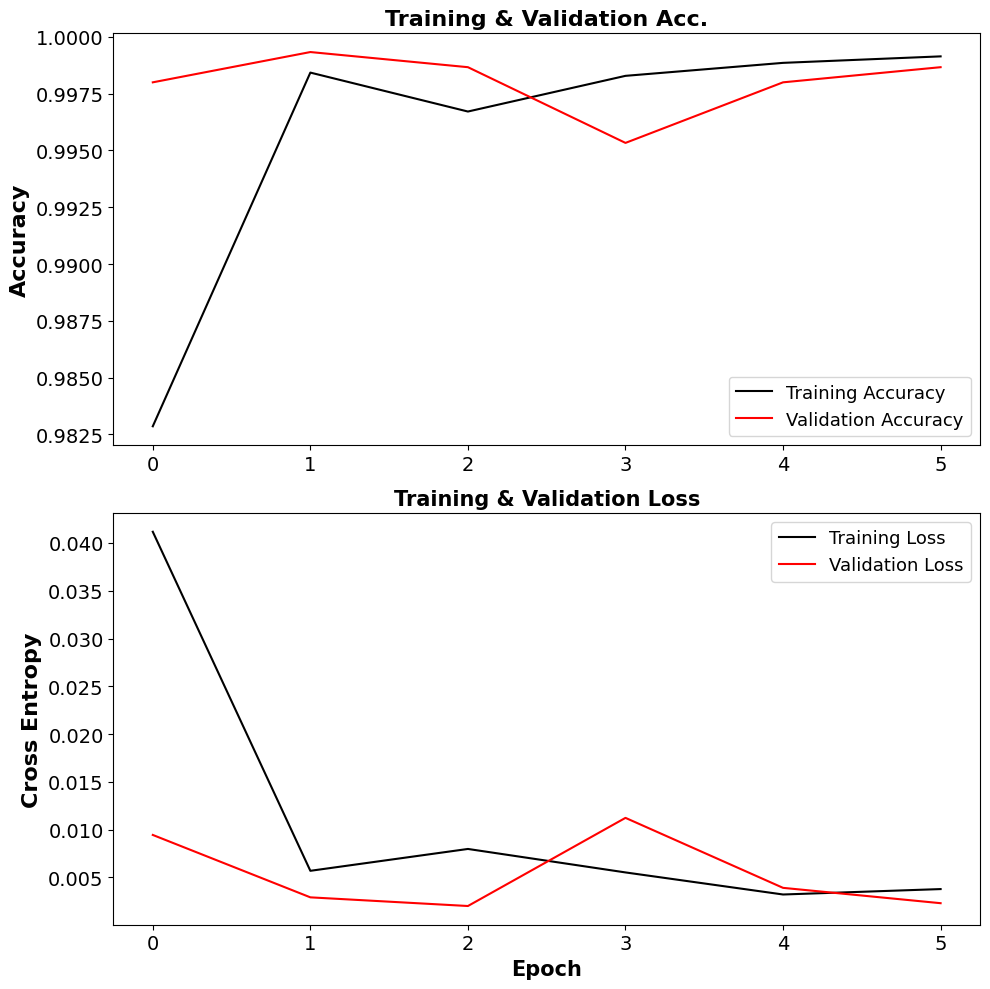

Saved: /content/exp-2-outputs/resnet50_training_curves.png


In [28]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(10, 10))
plt.subplot(2, 1, 1)

plt.plot(acc, label='Training Accuracy', color='black')
plt.plot(val_acc, label='Validation Accuracy', color='red')


plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(loc='lower right', fontsize=13)
plt.ylabel('Accuracy', fontsize=16, weight='bold')
plt.title('Training & Validation Acc.', fontsize=16, weight='bold')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss', color='black')
plt.plot(val_loss, label='Validation Loss', color='red')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(loc='upper right', fontsize=13)
plt.ylabel('Cross Entropy', fontsize=16, weight='bold')
plt.title('Training & Validation Loss', fontsize=15, weight='bold')
plt.xlabel('Epoch', fontsize=15, weight='bold')
plt.tight_layout()
TRAINING_CURVES_PATH = OUTPUT_DIR / 'resnet50_training_curves.png'
plt.savefig(TRAINING_CURVES_PATH, dpi=160, bbox_inches='tight')
plt.show()
print('Saved:', TRAINING_CURVES_PATH)


In [30]:
# Load the checkpoint selected only by validation loss.
best_model = keras.models.load_model(BEST_MODEL_PATH)
assert test_resnet.shuffle is False

test_resnet.reset()
test_metrics = best_model.evaluate(
    test_dataset, steps=len(test_resnet), return_dict=True, verbose=1
)

test_resnet.reset()
test_probabilities = best_model.predict(test_resnet, verbose=1).ravel()
y_true = np.asarray(test_resnet.classes, dtype=int)
y_pred = (test_probabilities >= 0.5).astype(int)

assert len(y_true) == len(test_df) == 1500
assert test_probabilities.shape == (1500,)
assert np.isfinite(test_probabilities).all()
assert ((test_probabilities >= 0.0) & (test_probabilities <= 1.0)).all()

target_names = ['benign', 'adenocarcinoma']
report = classification_report(
    y_true,
    y_pred,
    target_names=target_names,
    output_dict=True,
    zero_division=0,
)
print(classification_report(
    y_true, y_pred, target_names=target_names, digits=4, zero_division=0
))
print('Test metrics:', test_metrics)

47/47 ━━━━━━━━━━━━━━━━━━━━ 17s 232ms/step - accuracy: 0.9953 - loss: 0.0107 - precision: 0.9921 - recall: 0.9987 - roc_auc: 1.0000
47/47 ━━━━━━━━━━━━━━━━━━━━ 15s 247ms/step
                precision    recall  f1-score   support

        benign     0.9987    0.9920    0.9953       750
adenocarcinoma     0.9921    0.9987    0.9953       750

      accuracy                         0.9953      1500
     macro avg     0.9954    0.9953    0.9953      1500
  weighted avg     0.9954    0.9953    0.9953      1500

Test metrics: {'accuracy': 0.9953333139419556, 'loss': 0.010693587362766266, 'precision': 0.9920529723167419, 'recall': 0.9986666440963745, 'roc_auc': 0.9999733567237854}


In [32]:
def plot_confusion_matrix(cm, classes,
                          normalize=True,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title, weight='bold', fontsize=16)
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, fontsize=14)
    plt.yticks(tick_marks, classes, fontsize=14)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center", fontsize=12, weight='bold',
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label', fontsize=16, weight='bold')
    plt.xlabel('Predicted label', fontsize=16, weight='bold')

Normalized confusion matrix


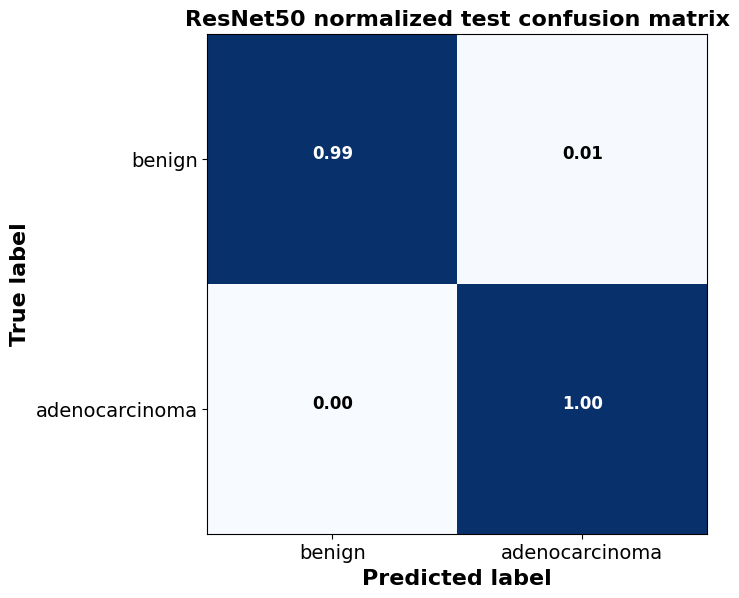

,benign,adenocarcinoma
benign,744,6
adenocarcinoma,1,749


In [33]:
cnf_matrix = confusion_matrix(y_true, y_pred, labels=[0, 1])
assert cnf_matrix.shape == (2, 2)
assert cnf_matrix.sum() == 1500

CONFUSION_MATRIX_PATH = OUTPUT_DIR / 'resnet50_confusion_matrix.csv'
CONFUSION_MATRIX_NORMALIZED_PATH = OUTPUT_DIR / 'resnet50_confusion_matrix_normalized.csv'
CONFUSION_MATRIX_PLOT_PATH = OUTPUT_DIR / 'resnet50_confusion_matrix.png'

cm_frame = pd.DataFrame(cnf_matrix, index=target_names, columns=target_names)
cm_frame.to_csv(CONFUSION_MATRIX_PATH)
cm_normalized = cnf_matrix / cnf_matrix.sum(axis=1, keepdims=True)
pd.DataFrame(cm_normalized, index=target_names, columns=target_names).to_csv(
    CONFUSION_MATRIX_NORMALIZED_PATH
)

plt.figure(figsize=(7, 7))
plot_confusion_matrix(
    cnf_matrix,
    classes=target_names,
    normalize=True,
    title='ResNet50 normalized test confusion matrix',
)
plt.savefig(CONFUSION_MATRIX_PLOT_PATH, dpi=160, bbox_inches='tight')
plt.show()
display(cm_frame)

In [34]:
METRICS_PATH = OUTPUT_DIR / 'resnet50_test_metrics.json'
REPORT_PATH = OUTPUT_DIR / 'resnet50_classification_report.json'
PREDICTIONS_PATH = OUTPUT_DIR / 'resnet50_test_predictions.csv'

metrics_evidence = {key: float(value) for key, value in test_metrics.items()}
metrics_evidence.update({
    'decision_threshold': 0.5,
    'test_samples': int(len(y_true)),
    'best_epoch': int(np.argmin(history.history['val_loss']) + 1),
    'best_validation_loss': float(np.min(history.history['val_loss'])),
})
METRICS_PATH.write_text(json.dumps(metrics_evidence, indent=2), encoding='utf-8')
REPORT_PATH.write_text(json.dumps(report, indent=2), encoding='utf-8')

prediction_evidence = test_df[['relative_path', 'class_name', 'label']].copy()
prediction_evidence['adenocarcinoma_probability'] = test_probabilities
prediction_evidence['predicted_label'] = y_pred
prediction_evidence['predicted_class'] = np.where(
    y_pred == 1, 'adenocarcinoma', 'benign'
)
prediction_evidence.to_csv(PREDICTIONS_PATH, index=False)

for artifact_path in [METRICS_PATH, REPORT_PATH, PREDICTIONS_PATH,
                      CONFUSION_MATRIX_PATH, CONFUSION_MATRIX_NORMALIZED_PATH,
                      CONFUSION_MATRIX_PLOT_PATH, TRAINING_CURVES_PATH]:
    assert artifact_path.is_file(), artifact_path
    print('Saved:', artifact_path)

Saved: /content/exp-2-outputs/resnet50_test_metrics.json
Saved: /content/exp-2-outputs/resnet50_classification_report.json
Saved: /content/exp-2-outputs/resnet50_test_predictions.csv
Saved: /content/exp-2-outputs/resnet50_confusion_matrix.csv
Saved: /content/exp-2-outputs/resnet50_confusion_matrix_normalized.csv
Saved: /content/exp-2-outputs/resnet50_confusion_matrix.png
Saved: /content/exp-2-outputs/resnet50_training_curves.png


In [35]:
import hashlib
import zipfile

def sha256_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with Path(path).open('rb') as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b''):
            digest.update(chunk)
    return digest.hexdigest()

assert BEST_MODEL_PATH.is_file()
model_sha256 = sha256_file(BEST_MODEL_PATH)
MODEL_MANIFEST_PATH = OUTPUT_DIR / 'resnet50_model_manifest.json'
model_manifest = {
    'model_id': 'resnet50-binary-colon',
    'artifact': BEST_MODEL_PATH.name,
    'format': 'keras_v3',
    'sha256': model_sha256,
    'size_bytes': BEST_MODEL_PATH.stat().st_size,
    'tensorflow_version': tf.__version__,
    'keras_version': keras.__version__,
    'input_shape': [224, 224, 3],
    'preprocessing': 'keras.applications.resnet50.preprocess_input',
    'class_mapping': {'benign': 0, 'adenocarcinoma': 1},
    'output': 'adenocarcinoma_probability',
    'decision_threshold': 0.5,
    'best_epoch': int(np.argmin(history.history['val_loss']) + 1),
    'selection_metric': 'val_loss',
}
MODEL_MANIFEST_PATH.write_text(
    json.dumps(model_manifest, indent=2), encoding='utf-8'
)

EVIDENCE_ARCHIVE_PATH = Path('/content/resnet50-exp-2-evidence.zip')
with zipfile.ZipFile(EVIDENCE_ARCHIVE_PATH, 'w', zipfile.ZIP_DEFLATED) as archive:
    for artifact_path in sorted(OUTPUT_DIR.iterdir()):
        if artifact_path.is_file() and artifact_path != BEST_MODEL_PATH:
            archive.write(artifact_path, arcname=artifact_path.name)

print('Best model:', BEST_MODEL_PATH)
print('SHA-256:', model_sha256)
print('Evidence archive:', EVIDENCE_ARCHIVE_PATH)

# Run these downloads before disconnecting the Colab runtime.
files.download(str(BEST_MODEL_PATH))
files.download(str(EVIDENCE_ARCHIVE_PATH))

Best model: /content/exp-2-outputs/resnet50_binary_best.keras
SHA-256: 02265f1280047a46d8c1c89826f1b331aaf834d49d6ad48d132033c0cac70594
Evidence archive: /content/resnet50-exp-2-evidence.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [37]:
from google.colab import files

files.download(
    "/content/exp-2-outputs/resnet50_binary_best.keras"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [38]:
import shutil
from google.colab import files

# Replace 'your_folder_name' with the exact name of the folder you want to download
shutil.make_archive("downloaded_folder", "zip", "/content/exp-2-outputs")

# This triggers the automatic browser download
files.download("downloaded_folder.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>